<a href="https://colab.research.google.com/github/emilyfeather/erg-2k-analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# erg-2k-analysis
## analytics!

scraping women's 2k times:

In [57]:
import pandas as pd

url = 'https://log.concept2.com/rankings/2025/rower/2000?rower=rower&gender=F'

tables = pd.read_html(url)
df = tables[1]
df.head() #show the first five rows to check all good

,Pos.,Name,Age,Location,Country,Club/Affiliation,Time,Verified
0,1,徐 軒,21,NaN,TPE,NaN,6:40.5,Yes
1,2,Lauren Henry,24,NaN,GBR,GB Rowing Team,6:40.9,Race
2,3,Vwaire Obukohwo,24,NaN,GBR,GB Rowing Team,6:43.7,Race
3,4,Elizabeth Gilmore,41,VA,USA,SPU,6:45.6,Race
4,5,Georgie Brayshaw,24,NaN,GBR,GB Rowing Team,6:45.8,Race


In [60]:
import time

frames = []
page = 1
while True:
    try:
        t = pd.read_html(url + f"&page={page}")
        if len(t[1]) == 0:
            break
        frames.append(t[1])

        slowest = t[1]["Time"].iloc[-1]                    # last row of this page
        parts = str(slowest).split(":")
        if int(parts[0]) * 60 + float(parts[1]) > 720:     # stop if past 12 min
            break

        page += 1
        time.sleep(1)
    except Exception:
        break

df = pd.concat(frames, ignore_index=True)
print(f"{page} pages, {len(df)} rows")
df.head()

48 pages, 2400 rows


,Pos.,Name,Age,Location,Country,Club/Affiliation,Time,Verified
0,1,徐 軒,21,NaN,TPE,NaN,6:40.5,Yes
1,2,Lauren Henry,24,NaN,GBR,GB Rowing Team,6:40.9,Race
2,3,Vwaire Obukohwo,24,NaN,GBR,GB Rowing Team,6:43.7,Race
3,4,Elizabeth Gilmore,41,VA,USA,SPU,6:45.6,Race
4,5,Georgie Brayshaw,24,NaN,GBR,GB Rowing Team,6:45.8,Race


In [61]:
df.to_csv("/content/drive/MyDrive/womens_2k.csv", index=False) # all women's times saved to a separate csv

scraping men's 2k times:

In [62]:
url2 = 'https://log.concept2.com/rankings/2026/rower/2000?rower=rower&gender=M'

tables = pd.read_html(url2)
df = tables[1]
df.head()

,Pos.,Name,Age,Location,Country,Club/Affiliation,Time,Verified
0,1,Michal Randa,21,NaN,POL,NaN,5:45.3,No
1,2,Tobias Schröder,26,NaN,GBR,GB Rowing Team,5:47.9,Race
2,3,Archie Drummond,23,NaN,GBR,GB Rowing Team,5:49.3,Race
3,4,Callum Dixon,25,NaN,GBR,GB Rowing Team,5:50.6,Race
4,5,Isak Zvegelj,25,NaN,SLO,NaN,5:50.7,Yes


In [63]:
frames = []
page = 1
while True:
    try:
        t = pd.read_html(url2 + f"&page={page}")
        if len(t[1]) == 0:
            break
        frames.append(t[1])

        slowest = t[1]["Time"].iloc[-1]                    # last row of this page
        parts = str(slowest).split(":")
        if int(parts[0]) * 60 + float(parts[1]) > 720:     # stop if past 12 min
            break

        page += 1
        time.sleep(1)
    except Exception:
        break

df = pd.concat(frames, ignore_index=True)
print(f"{page} pages, {len(df)} rows")
df.head()

162 pages, 8100 rows


,Pos.,Name,Age,Location,Country,Club/Affiliation,Time,Verified
0,1,Michal Randa,21,NaN,POL,NaN,5:45.3,No
1,2,Tobias Schröder,26,NaN,GBR,GB Rowing Team,5:47.9,Race
2,3,Archie Drummond,23,NaN,GBR,GB Rowing Team,5:49.3,Race
3,4,Callum Dixon,25,NaN,GBR,GB Rowing Team,5:50.6,Race
4,5,Isak Zvegelj,25,NaN,SLO,NaN,5:50.7,Yes


In [64]:
df.to_csv("/content/drive/MyDrive/mens_2k.csv", index=False) # all men's times saved to a separate csv

combining both sexes

In [65]:
m = pd.read_csv("/content/drive/MyDrive/mens_2k.csv")
w = pd.read_csv("/content/drive/MyDrive/womens_2k.csv")

m["sex"] = "M"
w["sex"] = "F"

df = pd.concat([m, w], ignore_index=True)
df.to_csv("/content/drive/MyDrive/all_2k.csv", index=False)
print(len(df))

10500


(expected length combining both sexes)

In [67]:
df = df.copy()

def to_seconds(t):
    parts = str(t).split(":")
    return int(parts[0]) * 60 + float(parts[1])

df["seconds"] = df["Time"].apply(to_seconds)

df["split"] = df["seconds"] / 4                # seconds per 500m
df["watts"] = 2.80 / (df["split"] / 500) ** 3  # Concept2's standard conversion

df = df[(df["Age"] >= 14) & (df["Age"] <= 90)] # drop nonsense ages

df.to_csv("/content/drive/MyDrive/all_2k_clean.csv", index=False)
df[["Name", "Age", "Time", "seconds", "split", "watts", "sex"]].head()

,Name,Age,Time,seconds,split,watts,sex
0,Michal Randa,21,5:45.3,345.3,86.325,544.074389,M
1,Tobias Schröder,26,5:47.9,347.9,86.975,531.967049,M
2,Archie Drummond,23,5:49.3,349.3,87.325,525.596254,M
3,Callum Dixon,25,5:50.6,350.6,87.650,519.771285,M
4,Isak Zvegelj,25,5:50.7,350.7,87.675,519.326783,M


##A first look at some analytics:

Mean watts for top 200 women and top 200 men:

In [76]:
import sqlite3
conn = sqlite3.connect("erg.db")

In [77]:
df.to_sql("rankings", conn, if_exists="replace", index=False)

10428

In [80]:
avg_watts = pd.read_sql("""
    SELECT sex, ROUND(AVG(watts),1) AS top200_avg_watts
    FROM rankings
    WHERE "Pos." <= 200
    GROUP BY sex
""", conn)
display(avg_watts)

,sex,top200_avg_watts
0,F,261.3
1,M,436.1


In [81]:
# power difference as a percentage of F watts:
men_watts = avg_watts[avg_watts['sex'] == 'M']['top200_avg_watts'].iloc[0]
women_watts = avg_watts[avg_watts['sex'] == 'F']['top200_avg_watts'].iloc[0]

power_gap_percentage = ((men_watts - women_watts) / women_watts) * 100
print(f"The power gap between men and women (as a percentage of women's watts) is: {power_gap_percentage:.1f}%")

The power gap between men and women (as a percentage of women's watts) is: 66.9%


Avg top men's watts are 66.9% greater than those of top women, but cube root law (taking mass into account) gives an 18% difference in actual boat speed terms - expected given the 15% difference in fastest erg times.

###Erg times by age category:

In [83]:
pd.read_sql("""
    SELECT sex,
           (Age/5)*5           AS age_band,
           COUNT(*)              AS n,
           ROUND(AVG(watts),1)   AS avg_watts
    FROM rankings
    GROUP BY sex, age_band
    ORDER BY sex, age_band
""", conn)

,sex,age_band,n,avg_watts
0,F,10,27,189.8
1,F,15,219,193.9
2,F,20,141,206.2
3,F,25,82,185.7
4,F,30,153,184.5
5,F,35,203,169.4
6,F,40,296,156.9
7,F,45,293,155.6
8,F,50,253,148.1
9,F,55,238,141.8


displaying age-sorted data:

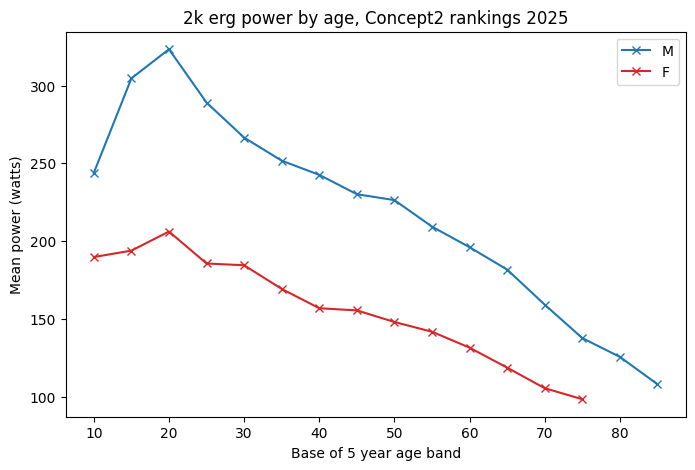

In [86]:
import matplotlib.pyplot as plt

ages = pd.read_sql("""
    SELECT sex, (Age/5)*5 AS age_band, COUNT(*) AS n, AVG(watts) AS avg_watts
    FROM rankings GROUP BY sex, age_band HAVING n >= 20
""", conn)

fig, ax = plt.subplots(figsize=(8, 5))
for s, colour in [("M", "tab:blue"), ("F", "tab:red")]:
    sub = ages[ages["sex"] == s]
    ax.plot(sub["age_band"], sub["avg_watts"], marker="x", color=colour, label=s)
ax.set_xlabel("Base of 5 year age band")
ax.set_ylabel("Mean power (watts)")
ax.set_title("2k erg power by age, Concept2 rankings 2025")
ax.legend()
plt.savefig("age_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Both sexes seem to average peak power output over 2km within the 20-24 year age category, with a gradual decline above this.

##Some visuals of the data by sex:

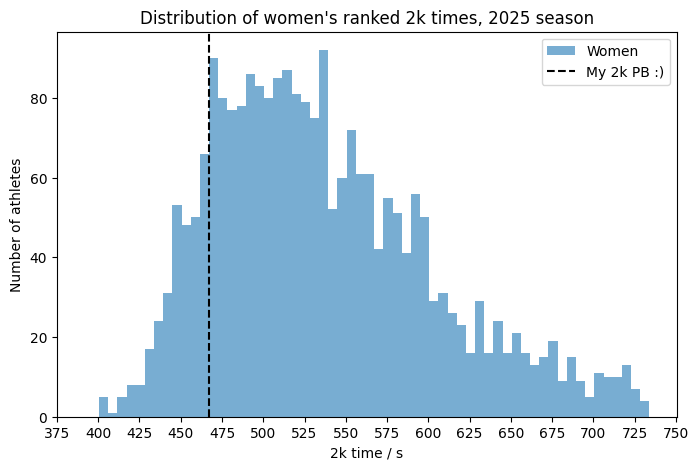

In [96]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df["sex"]=="F"]["seconds"], bins=60, alpha=0.6, label="Women")
ax.axvline(467, color="black", linestyle="--", label="My 2k PB :)")
ax.set_xlabel("2k time / s")
ax.set_ylabel("Number of athletes")
ax.set_title("Distribution of women's ranked 2k times, 2025 season")
ax.legend()

# Set x-axis labels with increments of 10 for the women's data
min_seconds_f_custom = 375
max_seconds_f_custom = 750
ax.set_xticks(np.arange(min_seconds_f_custom, max_seconds_f_custom + 1, 25))

plt.savefig("distribution.png", dpi=150, bbox_inches="tight")
plt.show()

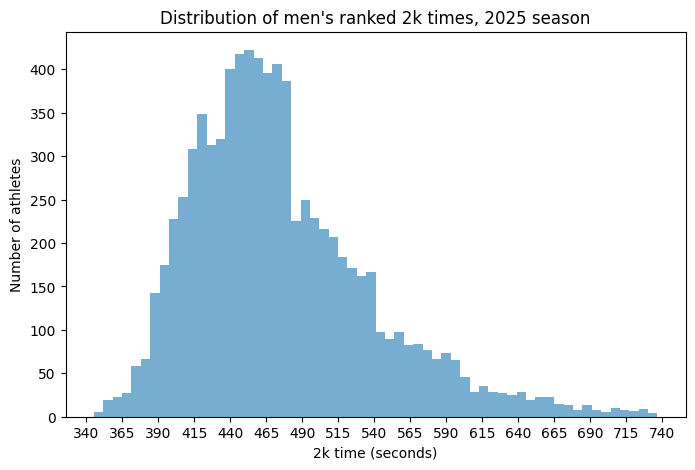

In [95]:
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df["sex"]=="M"]["seconds"], bins=60, alpha=0.6)
ax.set_xlabel("2k time (seconds)")
ax.set_ylabel("Number of athletes")
ax.set_title("Distribution of men's ranked 2k times, 2025 season")

# Add more x-axis labels to cover the whole span of the data with smaller increments
min_seconds_m = 340
max_seconds_m = 750
ax.set_xticks(np.arange(min_seconds_m, max_seconds_m + 1, 25))

plt.savefig("distribution.png", dpi=150, bbox_inches="tight")
plt.show()

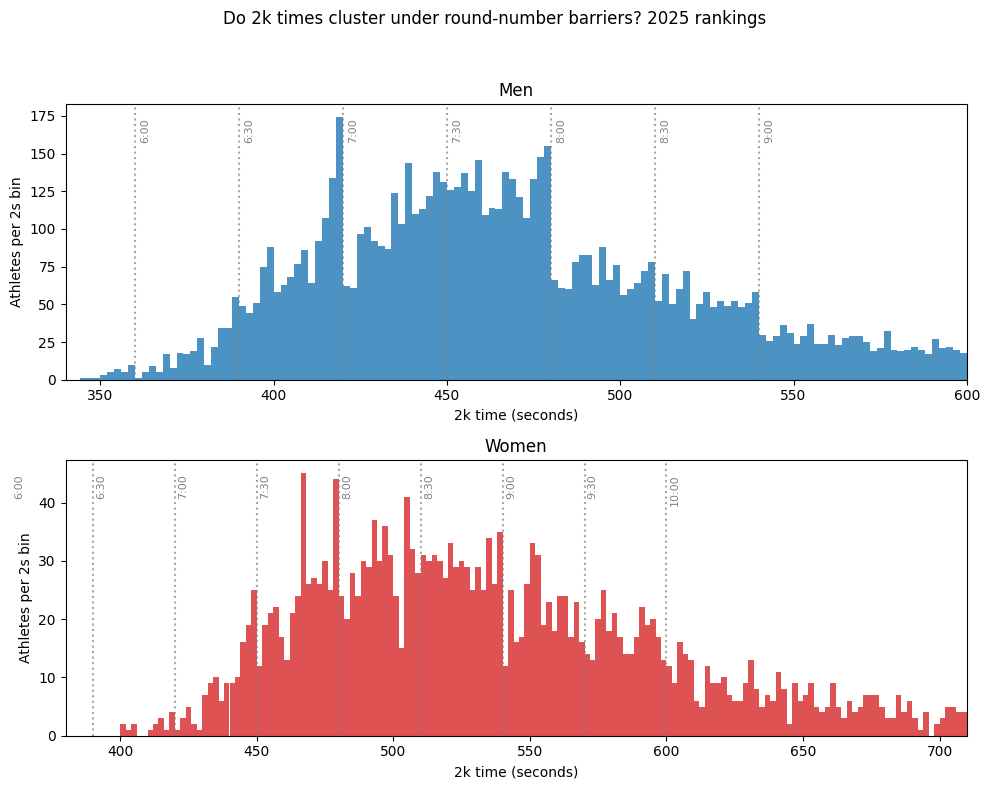

In [99]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8)) # Removed sharex=True
all_barriers = [360, 390, 420, 450, 480, 510, 540, 570, 600]

def format_seconds(seconds):
    minutes = int(seconds // 60)
    remaining_seconds = int(seconds % 60)
    return f"{minutes}:{remaining_seconds:02d}"

# Define the limits for men and women's plots
men_xlim = (340, 600) # Adjusted to end at 7:15
women_xlim = (380, 710) # Adjusted to start at 6:20 to give more room for labels

for i, (ax, s, colour, label) in enumerate([
    (axes[0], "M", "tab:blue", "Men"),
    (axes[1], "F", "tab:red", "Women"),
]):
    sub = df[df["sex"] == s]
    ax.hist(sub["seconds"], bins=range(340, 720, 2), color=colour, alpha=0.8)

    # Filter barriers based on sex
    current_barriers = all_barriers
    if s == "M":
        current_barriers = [b for b in all_barriers if b < 550] # Remove 7:30 and above for men

    for b in current_barriers:
        ax.axvline(b, color="grey", linestyle=":", alpha=0.7)
        # Add text label for each barrier
        ax.text(b + 3, ax.get_ylim()[1] * 0.95, format_seconds(b),
                rotation=90, va='top', ha='center', fontsize=8, color='gray')

    ax.set_ylabel("Athletes per 2s bin")
    ax.set_title(label)

    if s == "M":
        ax.set_xlim(men_xlim)
        ax.set_xlabel("2k time (seconds)") # Add xlabel for men's plot
    else:
        ax.set_xlim(women_xlim)
        ax.set_xlabel("2k time (seconds)") # Add xlabel for women's plot

fig.suptitle("Do 2k times cluster under round-number barriers? 2025 rankings", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to prevent overlapping title and subplots
plt.savefig("goal_bunching_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()

There is obvious clustering at the 7, 8 (and even 9) minute marks on the men's side. The women's side appears to be slightly more fluxional, although a cluster just below 8 minutes can be seen. In both cases, the number of athletes recording a time just below the threshold is over 2X the number recorded just above. I wonder whether clustering on the men's side being more prevalent than on the women's side is an indication of the psychology of how both sexes approach training/their 2k test?!